# **Conformal Prediction: A Simple Coding Tutorial**

Conformal prediction is a **reliable uncertainty quantification method for any machine learning model**.

In this tutorial, we will go through conformal prediction from first principles. We then create a class which can be used as a wrapper for any ML model!

This means we can output a set with guaranteed coverage, even for discrete cases, making prediction risk explicit.

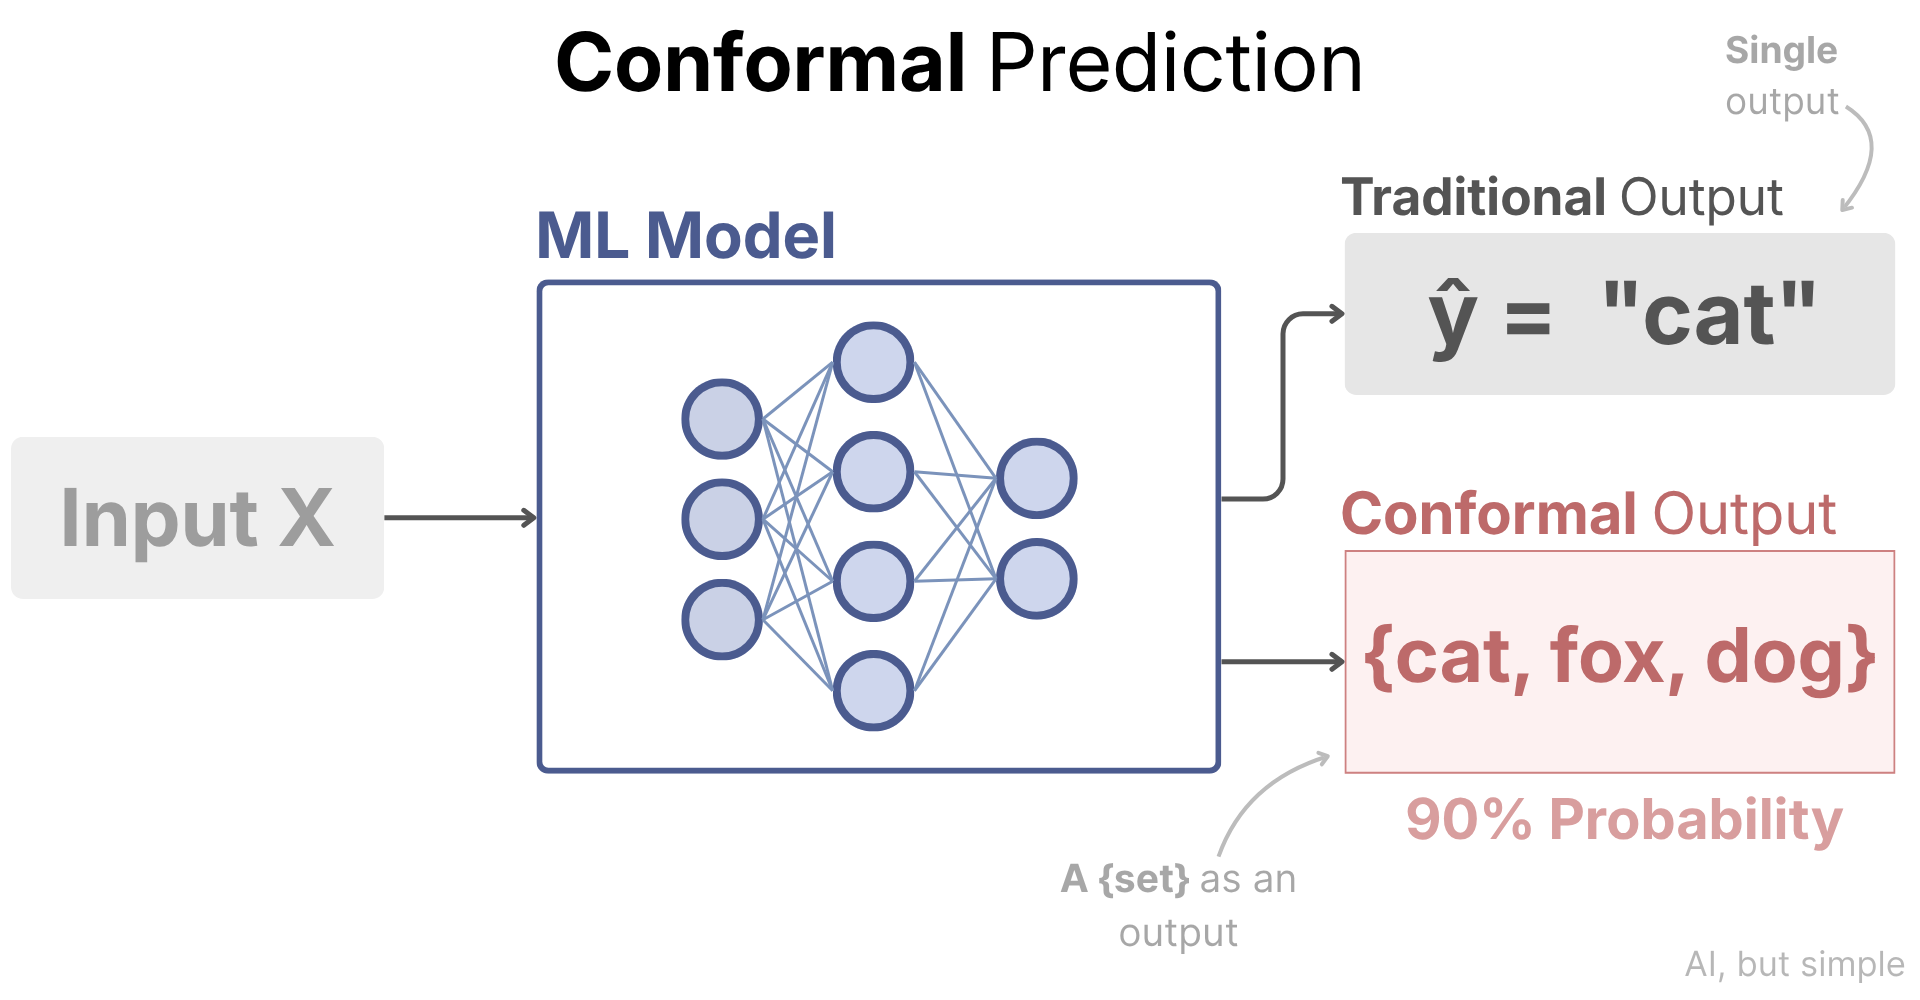

Please select the GPU in the runtime options. The code will have comments and explanations for clarity. Happy Learning!

—AI, But Simple Team


## **1. Setup & Imports**

First, let's import our key libraries:
* `sklearn` for machine learning models
* `matplotlib` for plots and visualization
* `numpy` for math operations
* `scipy` for sampling tests



In [ ]:
# Install dependencies if needed
# !pip install numpy scikit-learn matplotlib scipy

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import ks_2samp

# For reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Colors
PURPLE = '#534AB7'
TEAL   = '#0F6E56'
CORAL  = '#993C1D'
AMBER  = '#854F0B'

## **2. Foundations: The Core Guarantee**

Standard ML models output a single prediction. Conformal prediction wraps **any** model and produces a *set* with a provable coverage guarantee, with no distributional assumptions required.

> **The key promise:** given a user-chosen error rate $\alpha$, the true label falls inside the prediction set with probability **$≥ 1 − \alpha$**. This holds for any model and any data distribution, as long as data is *exchangeable*.

The process contains three key steps:
1. **Train** any model on training data (never calibration data)
2. **Calibrate** - compute nonconformity scores on held-out calibration set, find threshold `q`
3. **Predict** - at test time, output a set/interval using `q`

The **threshold formula** is defined below:

$$q = \text{Quantile}\left(\{s_1, \ldots, s_n\},\ \frac{\lceil(n+1)(1-\alpha)\rceil}{n}\right)$$



In [ ]:
# Compute corrected quantile level
def conformal_quantile(scores, alpha):
    """Compute the corrected conformal quantile threshold."""
    n = len(scores)
    level = np.ceil((n + 1) * (1 - alpha)) / n
    level = min(level, 1.0)          # clamp — can't exceed 1
    return np.quantile(scores, level)


# Show how the correction shrinks as n grows
ns = [10, 20, 50, 100, 200, 500, 1000]
alpha = 0.10
naive = 1 - alpha # 0.90 — what you'd use without the fix
corrected = [min(np.ceil((n+1)*(1-alpha))/n, 1.0) for n in ns]
diffs = [(c - naive) * 100 for c in corrected]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(ns, corrected, 'o-', color=PURPLE, linewidth=2, markersize=7)
axes[0].axhline(naive, color=CORAL, linestyle='--', linewidth=1.2, label=f'Naive level ({naive})')
axes[0].set_xlabel('Calibration set size n')
axes[0].set_ylabel('Quantile level')
axes[0].set_title('Corrected vs naive quantile level')
axes[0].legend()

axes[1].bar(range(len(ns)), diffs, color=PURPLE, alpha=0.7)
axes[1].set_xticks(range(len(ns)))
axes[1].set_xticklabels(ns)
axes[1].set_xlabel('Calibration set size n')
axes[1].set_ylabel('Correction size (%)')
axes[1].set_title('How much the correction matters')

plt.tight_layout()
plt.suptitle('The finite-sample correction (n+1)/n', y=1.02, fontsize=12)
plt.show()

print(f"{'n':>6}  {'Naive level':>12}  {'Corrected':>12}  {'Diff':>8}")
print("-" * 44)
for n, c, d in zip(ns, corrected, diffs):
    print(f"{n:>6}  {naive:>12.4f}  {c:>12.4f}  {d:>+7.2f}%")

## **3. Conformal Regression**

For regression, the nonconformity score is the **absolute residual**: $s_i = |y_i - \hat{y}_i|$.

The resulting prediction interval for a new point $x$ is:

$$\hat{C}(x) = [\hat{y} - q,\ \hat{y} + q]$$

This interval has **marginal** coverage guarantee that, the prediction set covers the true label with a probability of at least 1 - $\alpha$:

$$P(y \in \hat{C}(X)) \geq 1 - \alpha$$

We'll go through the conformal regression process, step-by-step below.

In [ ]:
# 1. Generate data - nonlinear signal + heteroskedastic noise
np.random.seed(0)
n_total = 600
X_all = np.sort(np.random.uniform(-3, 3, n_total))
noise = np.random.randn(n_total) * (0.5 + 0.5 * np.abs(X_all))   # noise grows with |x|
y_all = np.sin(X_all) * 2 + X_all * 0.5 + noise

X_all = X_all.reshape(-1, 1)

# 2. Three-way split: train / calibration / test
X_tr,   X_temp, y_tr,   y_temp = train_test_split(X_all, y_all, test_size=0.5, random_state=1)
X_cal,  X_te,   y_cal,  y_te   = train_test_split(X_temp, y_temp, test_size=0.5, random_state=2)

print(f"Train: {len(X_tr)} | Calibration: {len(X_cal)} | Test: {len(X_te)}")

# 3. Train a gradient boosting model
model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
model.fit(X_tr, y_tr)

# 4. Compute calibration nonconformity scores
y_cal_pred = model.predict(X_cal)
cal_scores = np.abs(y_cal - y_cal_pred)      # shape: (n_cal,)

# 5. Find threshold q for 90% coverage (alpha = 0.10)
alpha = 0.10
q = conformal_quantile(cal_scores, alpha)
print(f"\nCalibration scores: mean = {cal_scores.mean():.3f}, 90th percentile = {q:.3f}")
print(f"Prediction interval half-width: ±{q:.3f}")

# 6. Generate intervals on test set
y_te_pred = model.predict(X_te)
lo = y_te_pred - q
hi = y_te_pred + q

# 7. Measure empirical coverage
covered = (y_te >= lo) & (y_te <= hi)
print(f"\nTarget coverage: {1-alpha:.0%}")
print(f"Empirical coverage: {covered.mean():.1%} (should be ≥ {1-alpha:.0%})")

Let's visualize the prediction intervals on our test set.

In [ ]:
# Sort all values using the same indices
sort_idx = np.argsort(X_te.flatten())
x_sorted = X_te.flatten()[sort_idx]
y_sorted = y_te[sort_idx]
lo_sorted = lo[sort_idx]
hi_sorted = hi[sort_idx]
cov_sorted = covered[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: intervals + scatter
ax = axes[0]
ax.fill_between(x_sorted, lo_sorted, hi_sorted, alpha=0.2, color=PURPLE, label='90% interval')
ax.plot(x_sorted, model.predict(x_sorted.reshape(-1,1)), color=PURPLE, linewidth=1.5, label='ŷ')
ax.scatter(x_sorted[cov_sorted],  y_sorted[cov_sorted],  s=15, color=TEAL,  alpha=0.6, label='covered')
ax.scatter(x_sorted[~cov_sorted], y_sorted[~cov_sorted], s=25, color=CORAL, alpha=0.9,
           marker='x', linewidths=1.5, label='missed')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Conformal intervals - {covered.mean():.1%} empirical coverage')
ax.legend(fontsize=9)

# Right: distribution of calibration scores + q
ax2 = axes[1]
ax2.hist(cal_scores, bins=30, color=PURPLE, alpha=0.6, edgecolor='white', linewidth=0.4)
ax2.axvline(q, color=CORAL, linewidth=2, label=f'q = {q:.2f} (90th percntile)')
ax2.set_xlabel('Nonconformity score  |y − ŷ|')
ax2.set_ylabel('Count')
ax2.set_title('Calibration score distribution')
ax2.legend()

plt.tight_layout()
plt.show()

As coverage grows (and alpha decreases), the interval width grows to meet the target.

In [ ]:
alphas = np.linspace(0.01, 0.40, 40)
widths = []
empirical = []

for a in alphas:
    q_a   = conformal_quantile(cal_scores, a)
    lo_a  = y_te_pred - q_a
    hi_a  = y_te_pred + q_a
    widths.append(2 * q_a)
    empirical.append(np.mean((y_te >= lo_a) & (y_te <= hi_a)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(1 - alphas, widths, color=PURPLE, linewidth=2)
ax1.set_xlabel('Target coverage (1 - α)')
ax1.set_ylabel('Interval width (2q)')
ax1.set_title('Coverage target vs interval width')

ax2.plot(1 - alphas, empirical, color=TEAL, linewidth=2, label='Empirical coverage')
ax2.plot(1 - alphas, 1 - alphas, '--', color=CORAL, linewidth=1.5, label='Target (y=x)')
ax2.set_xlabel('Target coverage (1 - α)')
ax2.set_ylabel('Empirical coverage')
ax2.set_title('Guarantee in action: empirical ≥ target')
ax2.legend()

plt.tight_layout()
plt.show()

## **4. Conformal Classification**

For classification, instead of a point prediction we output a **set of plausible labels**.

The nonconformity score for sample $(x_i, y_i)$ is:

$$s_i = 1 - \hat{p}(y_i \mid x_i)$$

i.e., how much probability mass the model *didn't* put on the true class. At test time, we include class $k$ in the prediction set if $1 - \hat{p}(k \mid x) \leq q$, equivalently if $\hat{p}(k \mid x) \geq 1 - q$.

In [ ]:
# 1. Dataset: 4-class classification
X_clf, y_clf = make_classification(
    n_samples=1200, n_classes=4, n_informative=6,
    n_redundant=2, random_state=42
)
CLASS_NAMES = ['setosa', 'versicolor', 'virginica', 'unknown']

X_ctr, X_ctemp, y_ctr, y_ctemp = train_test_split(X_clf, y_clf, test_size=0.5, random_state=1)
X_ccal, X_cte, y_ccal, y_cte   = train_test_split(X_ctemp, y_ctemp, test_size=0.5, random_state=2)

# 2. Train classifier
clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=0)
clf.fit(X_ctr, y_ctr)
print(f"Model accuracy: {clf.score(X_cte, y_cte):.1%}")

# 3. Calibration nonconformity scores
probs_cal = clf.predict_proba(X_ccal) # (n_cal, 4)
cal_clf_scores = 1 - probs_cal[np.arange(len(y_ccal)), y_ccal]

# 4. Threshold
alpha_clf = 0.10
q_clf = conformal_quantile(cal_clf_scores, alpha_clf)
print(f"\nThreshold q = {q_clf:.4f}  (for {1-alpha_clf:.0%} coverage)")

# 5. Prediction sets on test set
probs_te = clf.predict_proba(X_cte)  # (n_test, 4)
pred_sets = probs_te >= (1 - q_clf)  # boolean mask

# 6. Metrics
covered_clf = pred_sets[np.arange(len(y_cte)), y_cte]
set_sizes   = pred_sets.sum(axis=1)

print(f"\nTarget coverage   : {1-alpha_clf:.0%}")
print(f"Empirical coverage: {covered_clf.mean():.1%}")
print(f"\nPrediction set size distribution:")
for sz in range(1, 5):
    pct = (set_sizes == sz).mean()
    bar = '|' * int(pct * 40)
    print(f"  Size {sz}: {bar:<40} {pct:.1%}")

Let's visualize the set size vs. model confidence, and coverage per class:


In [ ]:
max_probs = probs_te.max(axis=1) # model confidence for each test point

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: set size vs model confidence
ax = axes[0]
jitter = np.random.uniform(-0.15, 0.15, len(set_sizes))
ax.scatter(max_probs, set_sizes + jitter, alpha=0.25, s=10, color=PURPLE)
ax.set_xlabel('Model confidence (max softmax)')
ax.set_ylabel('Prediction set size')
ax.set_title('Confidence vs set size')
ax.set_yticks([1, 2, 3, 4])

# Middle: per-class coverage
ax2 = axes[1]
class_covs = [covered_clf[y_cte == c].mean() for c in range(4)]
colors_cc  = [TEAL if cv >= 1-alpha_clf else CORAL for cv in class_covs]
bars = ax2.bar(CLASS_NAMES, class_covs, color=colors_cc, alpha=0.8)
ax2.axhline(1 - alpha_clf, color=CORAL, linestyle='--', linewidth=1.5, label=f'Target {1-alpha_clf:.0%}')
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Coverage')
ax2.set_title('Per-class coverage (marginal guarantee)')
ax2.legend(fontsize=9)

# Right: coverage vs alpha
ax3 = axes[2]
alphas_clf = np.linspace(0.01, 0.5, 40)
covs_clf   = []
avg_sizes  = []
for a in alphas_clf:
    q_a  = conformal_quantile(cal_clf_scores, a)
    sets_a = probs_te >= (1 - q_a)
    covs_clf.append(sets_a[np.arange(len(y_cte)), y_cte].mean())
    avg_sizes.append(sets_a.sum(axis=1).mean())

ax3b = ax3.twinx()
ax3.plot(1 - alphas_clf, covs_clf,  color=TEAL,   linewidth=2, label='Coverage')
ax3.plot(1 - alphas_clf, 1 - alphas_clf, '--', color=CORAL, linewidth=1.2, label='Target')
ax3b.plot(1 - alphas_clf, avg_sizes, color=PURPLE, linewidth=1.5, linestyle=':', label='Avg set size')
ax3.set_xlabel('Target coverage')
ax3.set_ylabel('Coverage', color=TEAL)
ax3b.set_ylabel('Avg set size', color=PURPLE)
ax3.set_title('Coverage–efficiency tradeoff')
ax3.legend(loc='upper left', fontsize=9)
ax3b.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

Here, you can already observe that with a lower prediction set size, we have *higher* model confidence!

## **5. Adaptive Prediction Sets (RAPS)**

There's a problem with **softmax scores**: the threshold `q` is fixed for all inputs. An easy example (max softmax 0.98) and a hard one (max softmax 0.27) get the same treatment.

**RAPS** [(Regularised Adaptive Prediction Sets)](https://arxiv.org/pdf/2009.14193) fixes this by scoring based on the **cumulative softmax** of classes sorted by probability, until the true class is included. This naturally gives larger sets to harder examples.

$$s_i = \sum_{j=1}^{o(y_i)} \hat{p}_{(j)} + \lambda \cdot \max(0,\ o(y_i) - k_{\text{reg}})$$

where $o(y_i)$ is the rank of the true class when classes are sorted by softmax probability (highest first), and $\lambda$, $k_{\text{reg}}$ are regularisation hyperparameters.

In [ ]:
def raps_scores(probs, labels, lambda_reg=0.01, k_reg=5):
    """
    Compute RAPS calibration scores.

    Args:
        probs     : (n, K) softmax probabilities
        labels    : (n,)   true class indices
        lambda_reg: regularisation strength (penalises large sets)
        k_reg     : rank threshold below which no penalty applies
    Returns:
        scores    : (n,) nonconformity scores
    """
    n = len(labels)
    scores = np.zeros(n)
    for i in range(n):
        p = probs[i]
        # Sort classes from highest to lowest probability
        order = np.argsort(p)[::-1]
        # Rank of the true class (0-indexed)
        rank = int(np.where(order == labels[i])[0][0])
        # Cumulative sum up to and including true class
        cum_prob = np.sum(p[order[:rank + 1]])
        # Regularisation: penalise when true class rank > k_reg
        reg = lambda_reg * max(0, rank + 1 - k_reg)
        scores[i] = cum_prob + reg
    return scores


def raps_predict_sets(probs, q, lambda_reg=0.01, k_reg=5):
    """
    Build prediction sets using the RAPS rule:
    add classes in descending probability order until cumulative
    softmax (+ regularisation) exceeds q.
    """
    pred_sets = []
    for p in probs:
        order = np.argsort(p)[::-1]
        cum, chosen = 0, []
        for rank, cls in enumerate(order):
            cum += p[cls] + lambda_reg * max(0, rank + 1 - k_reg)
            chosen.append(cls)
            if cum > q:
                break
        pred_sets.append(set(chosen))
    return pred_sets


# Calibrate RAPS on the same calibration set
raps_cal_scores = raps_scores(probs_cal, y_ccal)
q_raps = conformal_quantile(raps_cal_scores, alpha_clf)
raps_sets = raps_predict_sets(probs_te, q_raps)

# Compare with fixed softmax sets
fixed_sets = [set(np.where(p >= 1 - q_clf)[0]) for p in probs_te]

raps_covered  = np.array([y_cte[i] in raps_sets[i]  for i in range(len(y_cte))])
fixed_covered = np.array([y_cte[i] in fixed_sets[i] for i in range(len(y_cte))])

raps_sizes  = np.array([len(s) for s in raps_sets])
fixed_sizes = np.array([len(s) for s in fixed_sets])

print("                   Fixed softmax     RAPS")
print("-" * 44)
print(f"Coverage         : {fixed_covered.mean():.1%}            {raps_covered.mean():.1%}")
print(f"Avg set size     : {fixed_sizes.mean():.2f}              {raps_sizes.mean():.2f}")
print(f"Size=1 (decisive): {(fixed_sizes==1).mean():.1%}           {(raps_sizes==1).mean():.1%}")
print(f"Size=4 (all cls) : {(fixed_sizes==4).mean():.1%}            {(raps_sizes==4).mean():.1%}")

Let's visualise adaptive vs fixed set sizes and confidence:


In [ ]:
# Create confidence intervals
confidence_bins = np.array([0.0, 0.35, 0.55, 0.75, 1.01])
bin_labels = ['very low\n(<0.35)', 'low\n(0.35–0.55)', 'high\n(0.55–0.75)', 'very high\n(>0.75)']
bin_idx = np.digitize(max_probs, confidence_bins) - 1

fixed_mean_by_bin = [fixed_sizes[bin_idx == b].mean() if (bin_idx==b).sum()>0 else 0 for b in range(4)]
raps_mean_by_bin  = [raps_sizes[bin_idx == b].mean() if (bin_idx==b).sum()>0 else 0 for b in range(4)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(4)
w = 0.35
axes[0].bar(x - w/2, fixed_mean_by_bin, w, label='Fixed (softmax)', color=CORAL, alpha=0.8)
axes[0].bar(x + w/2, raps_mean_by_bin, w, label='RAPS (adaptive)', color=PURPLE, alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bin_labels, fontsize=9)
axes[0].set_ylabel('Mean prediction set size')
axes[0].set_title('Set size by model confidence')
axes[0].legend()

# Score distribution comparison
axes[1].hist(1 - probs_cal[np.arange(len(y_ccal)), y_ccal],
             bins=30, alpha=0.6, color=CORAL,  label='Fixed softmax scores',  density=True)
axes[1].hist(raps_cal_scores,
             bins=30, alpha=0.6, color=PURPLE, label='RAPS scores', density=True)
axes[1].axvline(q_clf,  color=CORAL,  linestyle='--', linewidth=1.5, label=f'q (fixed) = {q_clf:.3f}')
axes[1].axvline(q_raps, color=PURPLE, linestyle='--', linewidth=1.5, label=f'q (RAPS) = {q_raps:.3f}')
axes[1].set_xlabel('Nonconformity score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score distributions')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

We see that the RAPS set sizes are consistently larger, with better coverage guarantees and more labels.

## **6. The ConformalPredictor Class**

Now we build a clean, reusable implementation of a Conformal Wrapper that wraps any scikit-learn compatible model.

In [ ]:
# ConformalPredictor can be used as drop-in wrapper for any sklearn model

class ConformalPredictor:
    """
    Split conformal predictor.

    Supports:
      - Regression  → guaranteed prediction intervals [ŷ - q, ŷ + q]
      - Classification → guaranteed prediction sets (softmax score)

    Usage:
        cp = ConformalPredictor(Ridge(), task='regression', alpha=0.10)
        cp.fit(X_train, y_train)
        cp.calibrate(X_cal, y_cal)
        lo, hi = cp.predict(X_test)
        print(cp.coverage(X_test, y_test))
    """

    def __init__(self, model, task='regression', alpha=0.10):
        assert task in ('regression', 'classification')
        self.model = model
        self.task  = task
        self.alpha = alpha
        self.q     = None

    def fit(self, X_train, y_train):
        """Train the underlying model."""
        self.model.fit(X_train, y_train)
        return self

    def calibrate(self, X_cal, y_cal):
        """Compute nonconformity scores and find threshold q."""
        scores = self._scores(X_cal, y_cal)
        n = len(scores)
        level = min(np.ceil((n + 1) * (1 - self.alpha)) / n, 1.0)
        self.q = np.quantile(scores, level)
        self._cal_scores = scores   # store for diagnostics
        return self

    def predict(self, X):
        """
        Regression    → (lower, upper) numpy arrays
        Classification → list of sets, one per sample
        """
        if self.q is None:
            raise RuntimeError("Call .calibrate() before .predict()")
        if self.task == 'regression':
            yhat = self.model.predict(X)
            return yhat - self.q, yhat + self.q
        else:
            probs = self.model.predict_proba(X)
            return [set(np.where(p >= 1 - self.q)[0]) for p in probs]

    def coverage(self, X_test, y_test):
        """Empirical coverage on a labelled test set."""
        if self.task == 'regression':
            lo, hi = self.predict(X_test)
            return float(np.mean((y_test >= lo) & (y_test <= hi)))
        else:
            pred_sets = self.predict(X_test)
            return float(np.mean([y in s for y, s in zip(y_test, pred_sets)]))

    def diagnostics(self):
        """Print a calibration summary."""
        if self.q is None:
            print("Not yet calibrated.")
            return
        s = self._cal_scores
        print(f"Task       : {self.task}")
        print(f"Alpha (α)  : {self.alpha}")
        print(f"Target cov : {1-self.alpha:.0%}")
        print(f"Threshold q: {self.q:.4f}")
        print(f"Cal scores — mean: {s.mean():.4f}, std: {s.std():.4f}, "
              f"min: {s.min():.4f}, max: {s.max():.4f}")

    def _scores(self, X, y):
        """Internal: compute nonconformity scores on a labelled set."""
        if self.task == 'regression':
            return np.abs(y - self.model.predict(X))
        else:
            probs = self.model.predict_proba(X)
            return 1 - probs[np.arange(len(y)), y]

# Demonstration:

# Regression
cp_reg = ConformalPredictor(GradientBoostingRegressor(random_state=0), alpha=0.05)
cp_reg.fit(X_tr, y_tr)
cp_reg.calibrate(X_cal, y_cal)
print("=== Regression (95% target) ===")
cp_reg.diagnostics()
print(f"Test coverage: {cp_reg.coverage(X_te, y_te):.1%}\n")

# Classification
cp_clf = ConformalPredictor(MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=0),
                             task='classification', alpha=0.10)
cp_clf.fit(X_ctr, y_ctr)
cp_clf.calibrate(X_ccal, y_ccal)
print("=== Classification (90% target) ===")
cp_clf.diagnostics()
print(f"Test coverage: {cp_clf.coverage(X_cte, y_cte):.1%}")

## **7. Validating the Guarantee Empirically**

The formal guarantee is non-asymptotic: it holds for **every finite dataset** (not just large n). Let's verify this by running many independent trials and checking that coverage stays above the target.

In [ ]:
# Monte Carlo validation (run 500 independent trials)
def run_conformal_trial(n_total=300, alpha=0.10, seed=None):
    """One full trial: generate data, train, calibrate, measure coverage."""
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((n_total, 2))
    y = X[:, 0] * 1.5 + X[:, 1] ** 2 + rng.standard_normal(n_total) * 1.2

    X_tr_, X_temp_, y_tr_, y_temp_ = train_test_split(X, y, test_size=0.5)
    X_cal_, X_te_,  y_cal_, y_te_  = train_test_split(X_temp_, y_temp_, test_size=0.5)

    model_ = Ridge()
    model_.fit(X_tr_, y_tr_)
    scores_ = np.abs(y_cal_ - model_.predict(X_cal_))
    q_ = conformal_quantile(scores_, alpha)

    yhat_ = model_.predict(X_te_)
    cov = np.mean((y_te_ >= yhat_ - q_) & (y_te_ <= yhat_ + q_))
    return cov

n_trials = 500
target_alpha = 0.10
coverages_mc = [run_conformal_trial(alpha=target_alpha, seed=i) for i in range(n_trials)]
coverages_mc = np.array(coverages_mc)

mean_cov = coverages_mc.mean()
min_cov  = coverages_mc.min()
pct_below = (coverages_mc < 1 - target_alpha).mean()

print(f"Trials          : {n_trials}")
print(f"Target coverage : {1-target_alpha:.0%}")
print(f"Mean coverage   : {mean_cov:.2%}")
print(f"Min coverage    : {min_cov:.2%}")
print(f"Trials below target: {pct_below:.1%}  ← should be small")

We plot the empirical distribution of coverage across trials below.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target = 1 - target_alpha

# Left: histogram of per-trial coverage
ax = axes[0]
bins = np.linspace(0.70, 1.0, 30)
colors_hist = [CORAL if b < target else TEAL for b in bins[:-1]]
n_hist, _, patches = ax.hist(coverages_mc, bins=bins, edgecolor='white', linewidth=0.4)
for patch, col in zip(patches, colors_hist):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.axvline(target, color='black', linewidth=2, linestyle='--', label=f'Target {target:.0%}')
ax.axvline(mean_cov, color=PURPLE, linewidth=1.5, linestyle='-', label=f'Mean {mean_cov:.2%}')
ax.set_xlabel('Empirical coverage per trial')
ax.set_ylabel('Number of trials')
ax.set_title(f'Coverage distribution over {n_trials} trials')
ax.legend()
miss_patch = mpatches.Patch(color=CORAL,  alpha=0.75, label=f'Below target ({pct_below:.1%})')
ok_patch   = mpatches.Patch(color=TEAL,   alpha=0.75, label='At or above target')
ax.legend(handles=[miss_patch, ok_patch], fontsize=9)

# Right: mean coverage as function of calibration set size
ax2 = axes[1]
n_cals = [10, 20, 50, 100, 200, 400]
mean_covs_by_n = []
for n_c in n_cals:
    covs = [run_conformal_trial(n_total=n_c*4, alpha=target_alpha, seed=i+1000) for i in range(100)]
    mean_covs_by_n.append(np.mean(covs))

ax2.plot(n_cals, mean_covs_by_n, 'o-', color=PURPLE, linewidth=2, markersize=7)
ax2.axhline(target, color=CORAL, linestyle='--', linewidth=1.5, label=f'Target {target:.0%}')
ax2.set_xlabel('Calibration set size')
ax2.set_ylabel('Mean coverage')
ax2.set_title('Coverage vs calibration set size')
ax2.legend()
ax2.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.suptitle('Empirical validation of the conformal guarantee', y=1.01, fontsize=12)
plt.show()

We can see above that coverage is not always exactly 90%, varying across trials due to randomness.

## **8. Summary**

| Concept | Key takeaway |
|---|---|
| Core guarantee | $P(y \in \hat{C}(X)) \geq 1-\alpha$ -> marginal, distribution-free, non-asymptotic |
| Threshold | $q = \text{Quantile}(s_{1:n},\ \lceil(n+1)(1-\alpha)\rceil/n)$ — the $(n+1)/n$ correction is essential |
| Regression | Score = $\|y - \hat{y}\|$, interval = $[\hat{y}-q, \hat{y}+q]$ |
| Classification | Score = $1-\hat{p}(y_i)$, set = $\{k : \hat{p}(k) \geq 1-q\}$ |
| Adaptive (RAPS) | Cumulative softmax score -> set size reflects local uncertainty |
